In [100]:
# install dependencies 
print("Installing dependencies...")
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib.ticker import FuncFormatter


import os 
import warnings 
warnings.filterwarnings("ignore")

# get root path of the project
PATH = os.path.dirname(os.getcwd())

print("All dependencies installed successfully!")
print(f"Current project directory: {PATH}")


Installing dependencies...
All dependencies installed successfully!
Current project directory: /Users/nadif/projects/hdi-recruitment


In [23]:
# read HDI daily ops data from csv file 
print("Reading HDI daily ops data...")
DATA_DIR = os.path.join(PATH, "data")
data_file = os.path.join(DATA_DIR, "raw", "hdi_daily_ops.csv")
if not os.path.exists(data_file):
    raise FileNotFoundError(f"Data file not found: {data_file}")

df = pd.read_csv(data_file)

print(f"Successfully read {df.shape[0]} rows and {df.shape[1]} columns from {data_file}!")

Reading HDI daily ops data...
Successfully read 1631 rows and 9 columns from /Users/nadif/projects/hdi-recruitment/data/raw/hdi_daily_ops.csv!


In [24]:
# get dataset information summary 
print("Displaying dataset information summary...\n")
print(df.info())

Displaying dataset information summary...

<class 'pandas.DataFrame'>
RangeIndex: 1631 entries, 0 to 1630
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   date                        1631 non-null   str  
 1   is_promo_period             1631 non-null   int64
 2   day_of_week                 1631 non-null   str  
 3   new_enterpriser_count       1631 non-null   int64
 4   new_bee_count               1631 non-null   int64
 5   transaction_volume_online   1631 non-null   int64
 6   transaction_volume_offline  1631 non-null   int64
 7   sales_ep_thousand_idr       1631 non-null   int64
 8   top_product_id              1631 non-null   str  
dtypes: int64(6), str(3)
memory usage: 114.8 KB
None


In [25]:
# get 5 top rows of the data 
print("Displaying the first 5 rows of the data...\n")
print(df.head())

Displaying the first 5 rows of the data...

         date  is_promo_period day_of_week  new_enterpriser_count  \
0  2022-01-01                0    Saturday                    180   
1  2022-01-02                0      Sunday                    168   
2  2022-01-03                0      Monday                    100   
3  2022-01-04                0     Tuesday                    136   
4  2022-01-05                0   Wednesday                    149   

   new_bee_count  transaction_volume_online  transaction_volume_offline  \
0            511                       3442                        1871   
1            478                       4137                        1621   
2            284                       2609                        1117   
3            387                       2876                        1611   
4            423                       3327                        1495   

   sales_ep_thousand_idr top_product_id  
0                1018482      Protein E  
1     

In [26]:
# check for missing values in the dataset 
print("Checking for missing values in the dataset...")
missing_values = df.isna().sum()
if missing_values.any():
    print("Missing values found in the dataset:\n")
    print(missing_values[missing_values > 0])
else:
    print("No missing values found in the dataset!")

Checking for missing values in the dataset...
No missing values found in the dataset!


In [29]:
print("Data preprocessing and cleaning...")

# data preprocessing and cleaning 
preprocessed_data_file = os.path.join(DATA_DIR, "processed", "hdi_daily_ops_cleaned.csv")
df_clean = df.copy()

# change the data type of "date" column to datetime 
print("...changing 'date' column to datetime data type...")
df_clean["date"] = pd.to_datetime(df_clean["date"], format="%Y-%m-%d")

# save the cleaned data to a new csv file
print(f"...saving cleaned data to {preprocessed_data_file}...")
df_clean.to_csv(preprocessed_data_file, index=False)

print("Data preprocessing and cleaning completed successfully!")
print(f"Preprocessed data is saved to: {preprocessed_data_file}")
print(f"Dataset shape after cleaning    : {df_clean.shape[0]} rows and {df_clean.shape[1]} columns.")
print(f"Dataset information summary after cleaning:")
print()
print(df_clean.info())




Data preprocessing and cleaning...
...changing 'date' column to datetime data type...
...saving cleaned data to /Users/nadif/projects/hdi-recruitment/data/processed/hdi_daily_ops_cleaned.csv...
Data preprocessing and cleaning completed successfully!
Preprocessed data is saved to: /Users/nadif/projects/hdi-recruitment/data/processed/hdi_daily_ops_cleaned.csv
Dataset shape after cleaning    : 1631 rows and 9 columns.
Dataset information summary after cleaning:

<class 'pandas.DataFrame'>
RangeIndex: 1631 entries, 0 to 1630
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        1631 non-null   datetime64[us]
 1   is_promo_period             1631 non-null   int64         
 2   day_of_week                 1631 non-null   str           
 3   new_enterpriser_count       1631 non-null   int64         
 4   new_bee_count               1631 non-null   int64   

In [33]:
# get statistical summary of the numerical columns in the dataset 
print("Displaying statistical summary of the numerical data in the dataset...\n")
print(df_clean.describe())

Displaying statistical summary of the numerical data in the dataset...

                      date  is_promo_period  new_enterpriser_count  \
count                 1631      1631.000000            1631.000000   
mean   2024-03-26 00:00:00         0.334764             222.828326   
min    2022-01-01 00:00:00         0.000000              73.000000   
25%    2023-02-12 12:00:00         0.000000             157.000000   
50%    2024-03-26 00:00:00         0.000000             197.000000   
75%    2025-05-07 12:00:00         1.000000             271.500000   
max    2026-06-19 00:00:00         1.000000             615.000000   
std                    NaN         0.472053              88.949189   

       new_bee_count  transaction_volume_online  transaction_volume_offline  \
count    1631.000000                1631.000000                 1631.000000   
mean      632.294911                5193.452483                 2215.088903   
min       208.000000                1820.000000             

In [ ]:
# get statistical summary of non-numerical columns in the dataset 
print("Displaying statistical summary of non-numerical data in the dataset...\n")
print(df_clean.describe(include=[object]))

Displaying statistical summary of non-numerical data in the dataset...

       day_of_week top_product_id
count         1631           1631
unique           7             10
top       Saturday   Supplement A
freq           233            346


In [35]:
# check if there is any missing date in the dataset 
print("Checking for missing days in the dataset...")
expected_dates = pd.date_range(
    start=df_clean["date"].min(),
    end=df_clean["date"].max(),
    freq="D",
)
missing_dates = expected_dates.difference(df_clean["date"])
if not missing_dates.empty:
    print("Missing days found in the dataset:\n")
    print(missing_dates)
else:
    print("No missing days found in the dataset!")

Checking for missing days in the dataset...
No missing days found in the dataset!


In [51]:
# get summary of daily operational data
# number of new registrations per day is calculated as the sum of "new_enterpriser_count" and "new_bee_count" columns 
daily_data = pd.DataFrame({
    "date": df_clean["date"],
    "new_registrations_count": df_clean["new_enterpriser_count"] + df_clean["new_bee_count"],
    "total_ep_sales": df_clean["sales_ep_thousand_idr"],
    "online_transaction_count": df_clean["transaction_volume_online"],
    "offline_transaction_count": df_clean["transaction_volume_offline"],
})

print("Displaying summary of all daily data...\n")
print(daily_data.drop("date", axis=1).describe().transpose())

Displaying summary of all daily data...

                            count          mean            std       min  \
new_registrations_count    1631.0  8.551232e+02     340.969594     281.0   
total_ep_sales             1631.0  1.481604e+06  518107.356846  535259.0   
online_transaction_count   1631.0  5.193452e+03    2067.656666    1820.0   
offline_transaction_count  1631.0  2.215089e+03     569.942252     954.0   

                                 25%        50%        75%        max  
new_registrations_count        603.0      755.0     1041.0     2360.0  
total_ep_sales             1100857.0  1353927.0  1755368.0  3397432.0  
online_transaction_count      3665.5     4562.0     6347.5    12916.0  
offline_transaction_count     1790.5     2147.0     2539.5     4452.0  


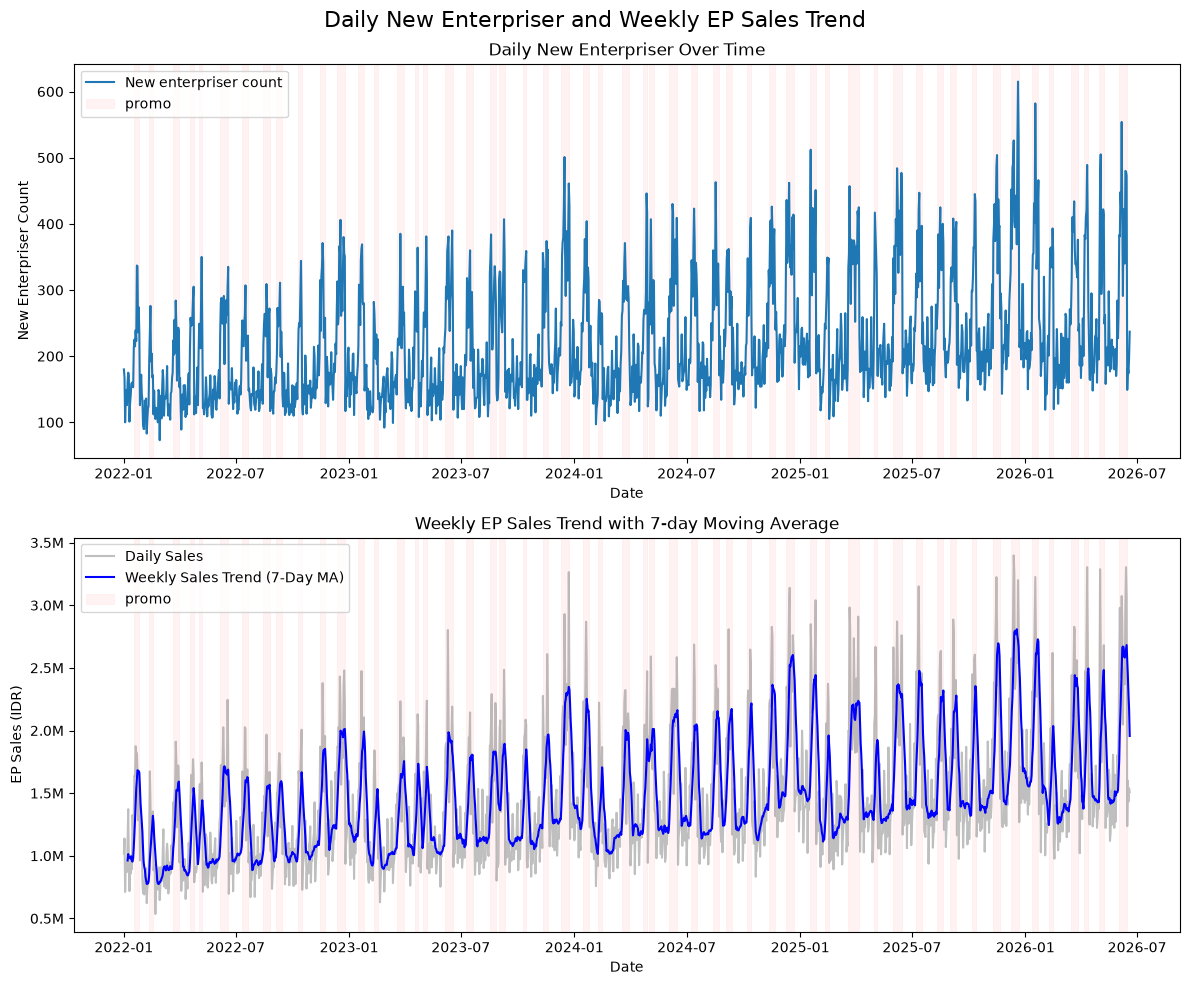

In [109]:
# create visualization for daily new enterpriser over time and weekly EP sales trend with 7-day moving average 
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
promo_date = df_clean[df_clean["is_promo_period"] == 1]["date"]
groups = (promo_date.diff().dt.days.ne(1).cumsum())
promo_ranges = (promo_date.groupby(groups).agg(["min", "max"]))


# seaborn style time series plot for daily new enterpriser over time
sns.lineplot(data=df_clean, 
             x="date", 
             y="new_enterpriser_count", 
             ax=axes[0],
             label="New enterpriser count",
             )

# seaborn style time series plot for weekly EP sales trend with 7-day moving average
sns.lineplot(data=df_clean, 
             x="date", 
             y="sales_ep_thousand_idr", 
             ax=axes[1], 
             label="Daily Sales", 
             alpha=0.5, 
             color="gray",
             )
sns.lineplot(data=df_clean, 
             x="date", 
             y=df_clean["sales_ep_thousand_idr"].rolling(window=7).mean(), 
             ax=axes[1], 
             label="Weekly Sales Trend (7-Day MA)", 
             color="blue"
             )

# add line mark to label promo period
for ax in axes:
    first = True
    for date in promo_ranges.itertuples():
        ax.axvspan(
            date.min,
            date.max,
            color="red",
            alpha=0.05,
            linewidth=0.5,
            label="promo" if first else None
        )
        first = False


plt.suptitle("Daily New Enterpriser and Weekly EP Sales Trend", fontsize=16)
axes[0].set_title("Daily New Enterpriser Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("New Enterpriser Count")
axes[0].legend()
axes[1].set_title("Weekly EP Sales Trend with 7-day Moving Average")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("EP Sales (IDR)")
axes[1].legend()
axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)

plt.tight_layout()
plt.show()